## Introduction to Langgraph

In [1]:
# Start by loading environment variables (OpenAI model endpoint and key)
import os

from dotenv import load_dotenv
load_dotenv('.env')
OPENAI_API_ENDPOINT=os.getenv("OPENAI_API_ENDPOINT")
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
AZURE_OPENAI_DEPLOYMENT_NAME=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")
OPENAI_API_VERSION=os.getenv("OPENAI_API_VERSION")

### Basic Chatbot
A basic application of langgraph starts with a stategraph. A stategraph object defines the structure of the application. Operations (Agents, functions, etc.) are defined as nodes on the graph and edges are used to define their connections (workflow). Stategraphs are the core to langgraph, and are defined using the START and END nodes.

In [2]:
# Import libraries:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

In [3]:
# Define a state. Note the use of Annotated here in order to specify to langgraph how the message should be handled:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function in the annotation defines how this state key
    # should be updated (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

# Initiate the stategraph with the defined state:
graph_builder = StateGraph(State)

In [4]:
# Define the LLM to use in the graph:
llm = init_chat_model(
    model="azure_openai:gpt-5-mini",
    model_provider='azure_openai',
    azure_endpoint=OPENAI_API_ENDPOINT,
    api_key=OPENAI_API_KEY,
    azure_deployment=AZURE_OPENAI_DEPLOYMENT_NAME,
    api_version=OPENAI_API_VERSION
)

In [5]:
# Incorporate the chat model into a simple node:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# Add node to the graph. The first argument is the unique node name, and the second is the object that will be called
# whenever the node is used:
graph_builder.add_node("chatbot", chatbot)

In [6]:
# Add start and end nodes to the graph:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [7]:
# Before running the graph, we need to compile it:
graph = graph_builder.compile()

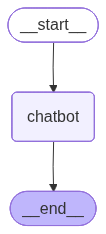

In [8]:
# You can visualize the graph using the get_graph method and one of the "draw" methods:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# To run the chatbot, first we create the current_state object to persist across turns:
current_state = {"messages": []}

# Then we define the stream function. Note the use of the graph.stream() method to get updates as they happen, and
# the event.values() method to get the updated state from the graph:
def stream_graph_updates(user_input: str):
    global current_state
    # Append the new user message to the persisted messages before streaming
    current_state["messages"] = current_state.get("messages", []) + [{"role": "user", "content": user_input}]

    # Call the graph with the full current state so the node can append the assistant reply
    for event in graph.stream(current_state):
        for value in event.values():
            # value["messages"] is the updated messages list from the graph; persist it
            current_state["messages"] = value["messages"]
            print("Assistant:", current_state["messages"][-1].content)

# Now we can create a basic script to run the chatbot:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: Note: this summary contains major spoilers.

Foundation is Isaac Asimov’s epic about the long decline and planned rebirth of a vast Galactic Empire. The central conceit is “psychohistory,” a fictional science developed by mathematician Hari Seldon that can predict the broad future behavior of very large populations. Seldon foresees the inevitable fall of the Galactic Empire and a 30,000-year dark age; to shorten the period of chaos to a mere 1,000 years he establishes a plan.

The Plan and the Foundations
- Seldon creates a “Foundation” on a remote, resource-poor world called Terminus, officially presented as an encyclopedia project to preserve knowledge. In secret, Terminus is meant to become the seed of a new, stable Galactic civilization.
- The series follows the Foundation’s evolution over centuries. It survives crises (“Seldon Crises”) predicted by Seldon’s recorded holograms that provoke the leaders to act in ways that keep the Plan on track.
- The First Foundation gro

### Adding tools to your AI application
We'll add the ability for our AI to search the web using a tool. The tool will access the Tavily search engine, a search engine specifically designed for AI factual research.

In [9]:
from langchain_tavily import TavilySearch
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [10]:
# Define the search tool:
tool = TavilySearch(max_results=2)
tools = [tool]

# Check to see that the tool works:
tool.invoke("Who won the nobel peace prize for physics in 2025?")

{'query': 'Who won the nobel peace prize for physics in 2025?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/cern/posts/cern-congratulates-the-winners-of-the-2025-nobel-prize-in-physics-john-clarke-mi/1231221152380945/',
   'title': 'CERN congratulates the winners of the 2025 Nobel Prize in ...',
   'content': 'CERN congratulates the winners of the 2025 Nobel Prize in #Physics John Clarke, Michel H. Devoret, and John M. Martinis were awarded the',
   'score': 0.8884594,
   'raw_content': None},
  {'url': 'https://www.aljazeera.com/news/2025/10/7/nobel-prize-for-physics-awarded-for-quantum-mechanic-tunnelling',
   'title': 'Nobel Prize in Physics awarded to trio for quantum mechanics ...',
   'content': "Skip links[Skip to Content](https://www.aljazeera.com/news/2025/10/7/nobel-prize-for-physics-awarded-for-quantum-mechanic-tunnelling#main-content-area) [](https://www.aljazeera.com/) Sign up[Enrich your Al Jazeera experienc

In [11]:
# Create a node class that calls the tool when invoked. The node checks the most recent message in the state
# and calls tools if the message contains tool_calls. It relies on the LLM's tool_calling support, which comes
# built in with multiple LLM model providers.
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        ''' Set of tools by name and the defined tool. '''
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        ''' Define tool's call behavior. '''
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}

# Create the tool node:
tool_node = BasicToolNode(tools=[tool])

In [12]:
# Let's define a new stategraph and add the tools to it. Start by binding tools to the same LLM object
# we defined before:
llm_with_tools = llm.bind_tools(tools)
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [13]:
# Add nodes to the graph:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)

In [14]:
# Add conditional edges. Conditional edges determine the processing path through the graph, usually based
# on the current state. These functions take the current state and returns a string or list of strings indicating
# the next node(s) to process. 
def route_tools(state: State):
    """
    Use in the conditional_edge to route to the ToolNode if the last message has tool calls; otherwise route to END.
    """
    # Extract the last message from the state:
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    # Conditional routing based on whether the last message from the LLM has tool calls:
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    else:
        return END

# Add the conditional edge to the graph using the `route_tools` function. As can be seen, this function returns
# "tools" if the chatbot asks to use a tool and "END" if it is fine directly responding.
graph_builder.add_conditional_edges(
    "chatbot", route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node.
    {"tools": "tools", END: END},
)

In [15]:
# Complete the graph by adding final connecting edges. Any time a tool is called, we return to the chatbot
# to decide the next step. Note that we don't need to add END as it is already handled in the conditional edge above.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

In [22]:
# Visualize the updated graph as before:
print(graph.get_graph().draw_ascii())

        +-----------+         
        | __start__ |         
        +-----------+         
               *              
               *              
               *              
          +---------+         
          | chatbot |         
          +---------+         
          .         .         
        ..           ..       
       .               .      
+---------+         +-------+ 
| __end__ |         | tools | 
+---------+         +-------+ 


In [23]:
# Let's try the chatbot as before:
current_state = {"messages": []}

def stream_graph_updates(user_input: str):
    global current_state
    current_state["messages"] = current_state.get("messages", []) + [{"role": "user", "content": user_input}]

    print(f'\n--------------------------------\nUser: {user_input}\n')
    for event in graph.stream(current_state):
        for value in event.values():
            current_state["messages"] = value["messages"]
            print("Assistant:", current_state["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break


--------------------------------
User: Tell me about the nobel prize

Assistant: Short overview
- The Nobel Prize is a set of international awards given annually to individuals and organizations that the Nobel committees consider to have conferred the greatest benefit to humankind in specific fields. The prizes were established by the 1895 will of Swedish inventor and industrialist Alfred Nobel.

History and founder
- Alfred Nobel (1833–1896) left most of his fortune to create prizes in his will. The first prizes were awarded in 1901.
- The original will named prizes in Physics, Chemistry, Physiology or Medicine, Literature, and Peace.

Current categories and who awards them
- Physics and Chemistry: Royal Swedish Academy of Sciences.
- Physiology or Medicine: Nobel Assembly at Karolinska Institutet.
- Literature: Swedish Academy.
- Peace: Norwegian Nobel Committee (awarded in Oslo).
- The Sveriges Riksbank Prize in Economic Sciences in Memory of Alfred Nobel (commonly called the Nobel

### Adding Memory using persistent checkpoints
So far we've been manually maintaining the message history by creating a global `current_state` variable and iterativelly updating it during event streaming. This can be handled much more efficiently persistent checkpoints.

By provide a `checkpointer` when compiling the graph and a `thread_id` when calling your graph, LangGraph automatically saves the state after each step. When you invoke the graph again using the same thread_id, the graph loads its saved state, allowing the chatbot to pick up where it left off.

In [ ]:
# Create a memory checkpointer. The InMemorySaver stores checkpoints in memory. For production use,
# consider using a more persistent storage solution, such as a database or file system.
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

In [25]:
# Compile the graph with the checkpointer, which will checkpoint the State as the graph works through each node:
graph = graph_builder.compile(checkpointer=memory)

In [26]:
# Let's call the chatbot again, this time providing a thread_id to persist the state across calls:
config = {"configurable": {"thread_id": "1"}}

# Event stream again, but this time the state is automatically loaded and saved by the checkpointer:
def stream_graph_updates(user_input: str):
    print(f'\n--------------------------------\nUser: {user_input}\n')
    # The config variable is the second positional argument for the stream() or invoke() functions
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}, config):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    stream_graph_updates(user_input)


--------------------------------
User: Tell me about some current events

Assistant: 
Assistant: 
Assistant: {"query": "major climate disasters wildfires hurricanes October 2025", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://disasterresiliencenews.com/2025/10/02/today-in-disaster-resilience-3-october-2025/", "title": "Today in disaster resilience (3 October 2025)", "content": "As Hurricanes Stir Up Coastal Waters, North Carolina Homes Collapse Into the Sea\n\nVolcanic activity worldwide 30 Sep 2025: Santiaguito volcano, Fuego, Karymsky, Popocat\u00e9petl \n\nExtreme Weather and Climate Change\n\n\u2018It\u2019s not us anymore\u2019: Renewables go from boom to bust in the wind capital of Canada \n\nAbnormally hot days may hit Australia\u2019s south-east after rare sudden warming over Antarctica \n\nTransport will make or break Australia\u2019s new climate plan \u2013 and time is running out to fix it [...] Skip to content \n\nDisaster Resilien

In [29]:
# We can inspect the state saved in memory by using graph.get_state():
snapshot = graph.get_state(config)
snapshot.values

{'messages': [HumanMessage(content='Tell me about some current events', additional_kwargs={}, response_metadata={}, id='edf6787d-892f-4b49-9adf-452df43466c0'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_haiMXMTo4KAPo3OwzyR9o6sb', 'function': {'arguments': '{"query": "top world news today", "search_depth": "advanced", "topic": "news", "time_range": "day"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'call_SXv0ip2EdAXLmpGAkm2p78F1', 'function': {'arguments': '{"query": "Israel Gaza latest October 2025", "search_depth": "advanced", "topic": "news", "time_range": "week"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'call_6xzdTOQkAuwAGLzKchtd6mR4', 'function': {'arguments': '{"query": "Ukraine Russia war latest October 2025", "search_depth": "advanced", "topic": "news", "time_range": "week"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'call_yJb8r5pDcKMbS9K9NmPdI9AV', 'function': {'arguments': '{"query": "global markets today Octo